<h2 style="color: red;"> Sentinel2 images exploration and visualisation with Python and Rasterio </h2>

In this exercise, we will cover the following:

 - read Sentinel-2 multispectral bands,
 - create RGB and false-colour composites,
 - save a multiband GeoTIFF,
 - visualise multispectral imagery.

## Import required libraries

In [1]:
import zipfile
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np 

<p style="color:blue;font-size:13pt">Sentinel-2 products are commonly distributed as compressed archives. The first step is to extract the required files.</p>

In [2]:
import zipfile   # Open the zip file
fileName='./input_data/S2A_MSIL1C_20230815T095031_N0509_R079_T33TXJ_20230815T133204.SAFE.zip'
with zipfile.ZipFile(fileName, 'r') as zip_ref:
    zip_ref.extractall('extracted_files2')  # Extract the files
# The extracted files will be in the 'extracted_files' directory


#### Each Sentinel-2 band represents a different part of the electromagnetic spectrum.

In [3]:
filePath = ('extracted_files2/S2A_MSIL1C_20230815T095031_N0509_R079_T33TXJ_20230815T133204.SAFE/GRANULE/L1C_T33TXJ_A042547_20230815T095630/IMG_DATA/')
band2= rio.open(filePath+'T33TXJ_20230815T095031_B02.jp2')  # blue
band3 = rio.open(filePath+'T33TXJ_20230815T095031_B03.jp2') # green
band4 = rio.open(filePath+'T33TXJ_20230815T095031_B04.jp2') # red
band8 = rio.open(filePath+'T33TXJ_20230815T095031_B08.jp2') # nir

In [4]:
#number of raster bands, number of raster columns, number of raster rows
#type of raster byte,raster sytem of reference,
band4.count, band4.width, band4.height, band4.dtypes[0], band4.crs


(1, 10980, 10980, 'uint16', CRS.from_epsg(32633))

In [6]:
#raster values as matrix array
band4.read(1)


array([[1830, 1786, 1750, ..., 1752, 1643, 1562],
       [1824, 1762, 1770, ..., 1716, 1612, 1610],
       [1821, 1842, 1822, ..., 1641, 1600, 1653],
       ...,
       [1344, 1345, 1339, ..., 1775, 1765, 1790],
       [1353, 1344, 1344, ..., 1797, 1788, 1763],
       [1355, 1345, 1350, ..., 1864, 1858, 1873]], dtype=uint16)

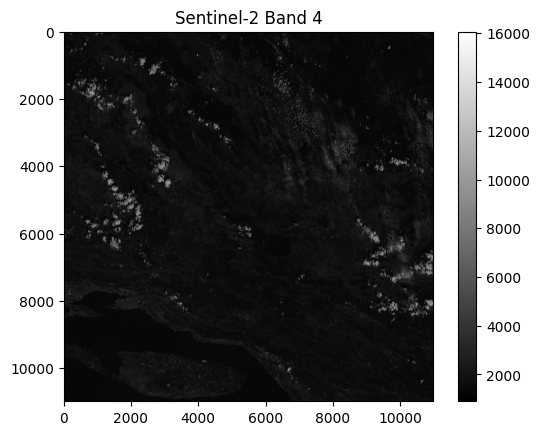

In [5]:
# Plot the band using imshow

fig, ax = plt.subplots()  # Create a figure and a single subplot
cax = ax.imshow(band4.read(1),cmap='gray')  # Display the image, with a colormap of your choice
fig.colorbar(cax, ax=ax)  # Add a colorbar associated with the image
ax.set_title('Sentinel-2 Band 4')  # Set a title for your plot

plt.show()  # Show the plot

### Task 1. Visualizing Multiple Sentinel-2 Bands
Complete the following code to display the Blue, Green, and Red Sentinel-2 bands in a single figure. Use appropriate colour maps for each band and arrange the plots in one row.


In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
show(____, ax=ax1, cmap='____')   	# Blues
show(____, ax=ax2, ____)  		# Greens
show(____, ax=ax3, ____)    		# Reds

ax1.set_title("__________")
ax2.set_title("__________")
ax3.set_title("__________")

fig.tight_layout()
plt.show()


SyntaxError: positional argument follows keyword argument (1490472943.py, line 3)

<h2 style="color: rgb(0,112,192)";">True Color Composition</h2>

<p style="font-size:14pt;">A true-colour composite uses the visible red, green and blue bands to approximate what the human eye would see.</p>

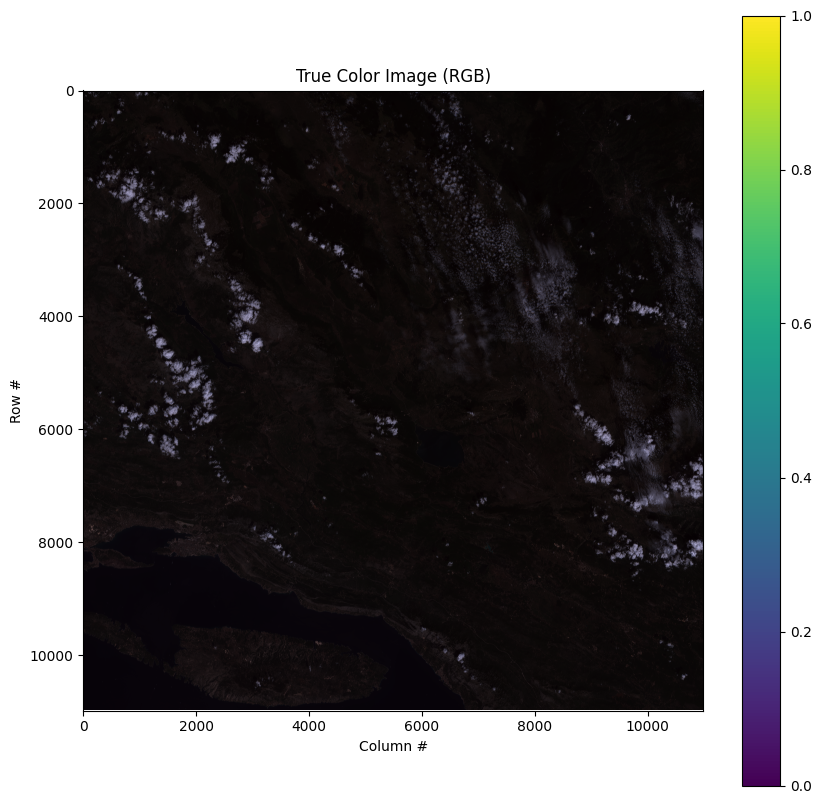

In [16]:
red = band4.read(1).astype('float64')
green = band3.read(1).astype('float64')
blue = band2.read(1).astype('float64')

    # Normalize the bands to the range 0-1
red_norm = (red - red.min()) / (red.max() - red.min())
green_norm = (green - green.min()) / (green.max() - green.min())
blue_norm = (blue - blue.min()) / (blue.max() - blue.min())

    # Stack the bands into an RGB array
rgb_norm = np.stack((red_norm, green_norm, blue_norm), axis=2)

# Visualize the true color image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_norm)
plt.colorbar()  # Optional, may not be necessary for RGB but here for completeness
plt.title('True Color Image (RGB)')
plt.xlabel('Column #')
plt.ylabel('Row #')

# Save the plot to a file
plt.savefig('./Output_Data/Ex3_True_ColorComposite.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

<h2 style="color: rgb(0,111,199);">False Color Composition</h2>
<p style="font-size:13pt;">A false-colour composite replaces one or more visible bands with <span style="color:blue;font-size:13pt">the Near Infrared (NIR) </span> band to enhance vegetation and facilitate land-cover interpretation. In this exercise, the normalized <span style="color:blue;font-size:13pt">Red and Green bands</span> created previously are reused, while <span style="color:blue;font-size:13pt">Band 8 (NIR)</span> is additionally normalized and assigned to the red display channel. As a result, healthy vegetation appears in shades of red, making vegetated areas easier to distinguish from urban surfaces, bare soil, and water.</p>

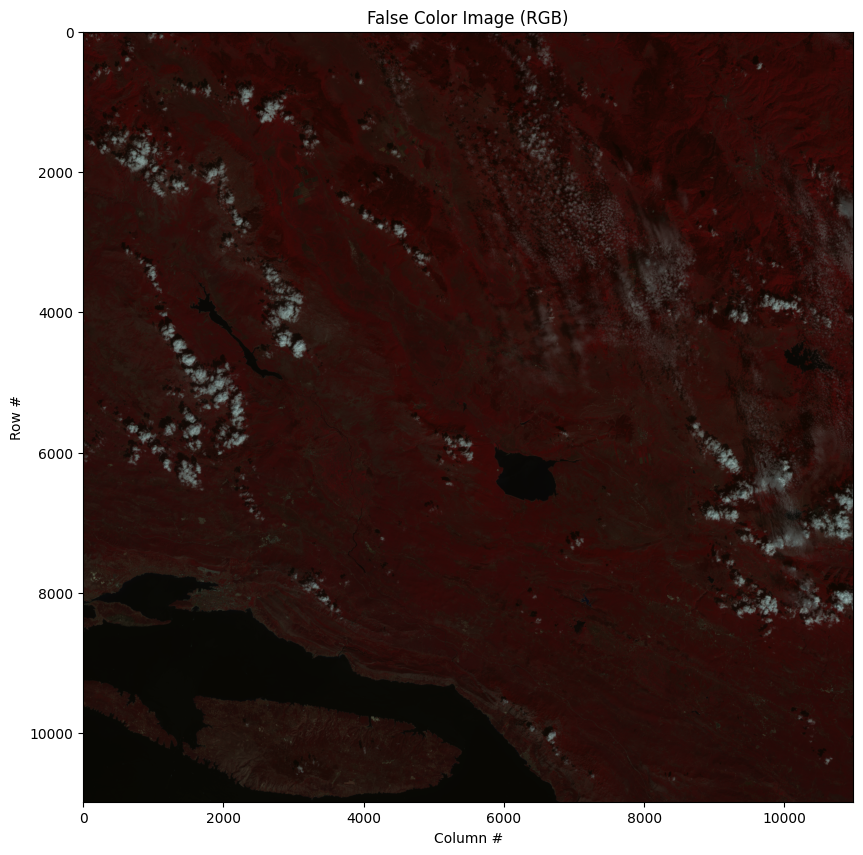

In [15]:
nir=(band8.read(1))  #NIR

 # Normalize NIR bands to the range 0-1
nir_norm = (nir - nir.min()) / (nir.max() - nir.min())

false_norm = np.dstack((nir_norm ,red_norm ,green_norm ))

 # Setup the plot
plt.figure(figsize=(10, 10))
plt.imshow(false_norm)
plt.title('False Color Image (RGB)')
plt.xlabel('Column #')
plt.ylabel('Row #')

# Save the plot to a file
plt.savefig('./Output_Data/Ex3_False_ColorComposite.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

## References

https://hatarilabs.com/ih-en/sentinel2-images-explotarion-and-processing-with-python-and-rasterio